In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
boxoffice = pd.read_csv('2026-04-30_boxoffice_v2.csv')

In [4]:
boxoffice_counts = boxoffice.groupby(['year','genre']).size().unstack(fill_value=0) #groups by year and genre

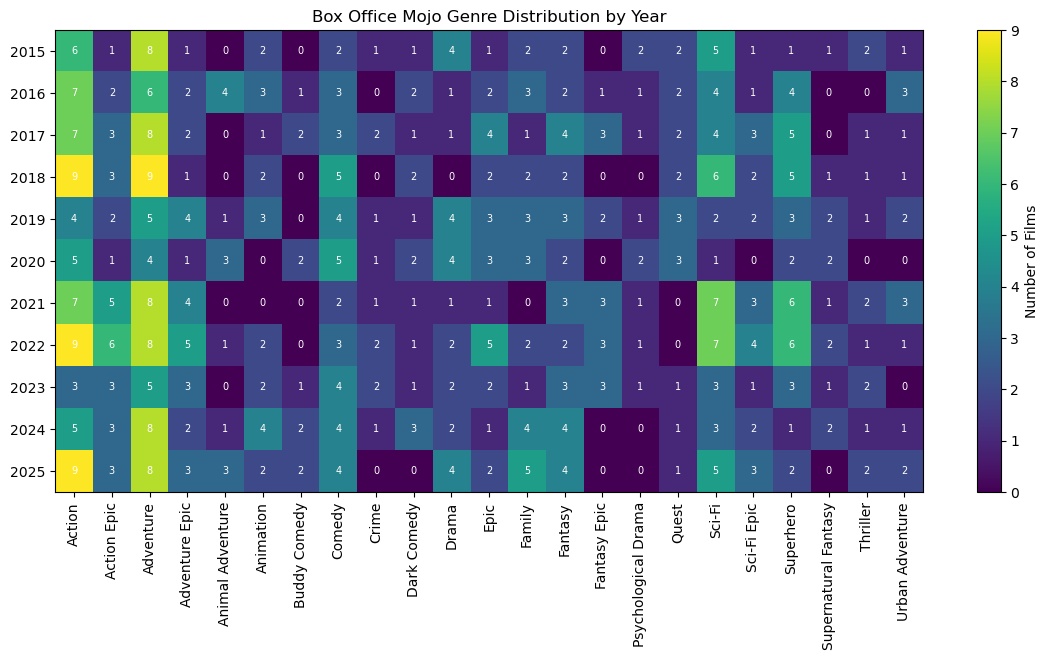

In [5]:
boxoffice_filtered = boxoffice_counts.loc[
    :, boxoffice_counts.sum() >=10 #filters out genres that come up less than 10 times
    ]
fig, ax = plt.subplots(figsize = (14,6))
heatmap = ax.imshow(boxoffice_filtered, aspect='auto') #creates heatmap

ax.set_xticks(range(len(boxoffice_filtered.columns)))
ax.set_yticks(range(len(boxoffice_filtered.index)))
ax.set_xticklabels(boxoffice_filtered.columns, rotation=90)
ax.set_yticklabels(boxoffice_filtered.index)

for i in range(len(boxoffice_filtered.index)): #adds count of genre appearance in each box
    for j in range(len(boxoffice_filtered.columns)):
        val = boxoffice_filtered.iloc[i,j]
        ax.text(j, i, int(val),
                     ha='center', va='center', fontsize=7, color='white')

ax.set_title('Box Office Mojo Genre Distribution by Year')
plt.colorbar(heatmap, ax=ax, label= 'Number of Films')
fig.savefig('boxofficeheatmap.jpg')

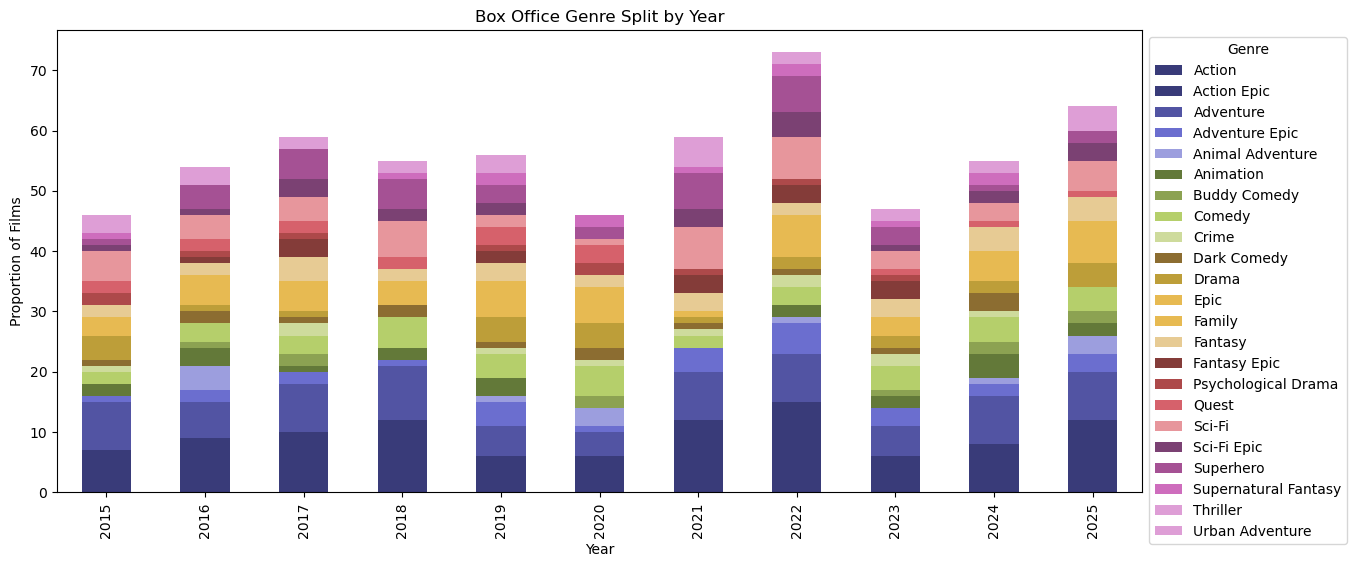

In [7]:
ax = boxoffice_filtered.plot(kind='bar', figsize=(14,6),stacked=True,colormap='tab20b') #creates stacked bar graph
ax.set_title('Box Office Genre Split by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion of Films')
ax.legend(title='Genre',loc='upper left', bbox_to_anchor=(1,1)) #provides color correspondence for each genre
fig.savefig('boxofficestackedbar.jpg')

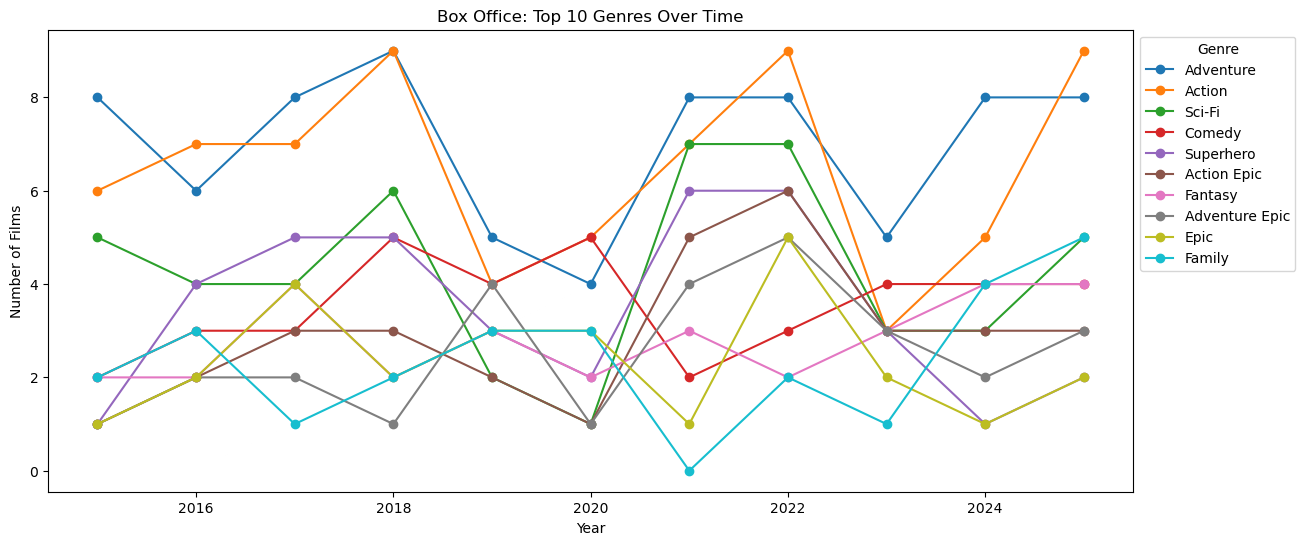

In [8]:
top_genres = boxoffice_filtered.sum().nlargest(10).index #filters the 10 most occuring genres
fig, ax = plt.subplots(figsize=(14,6))

for i in top_genres:
    ax.plot(
        boxoffice_filtered.index,
        boxoffice_filtered[i],
        marker='o',
        label=i)
ax.set_title('Box Office: Top 10 Genres Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Films')
ax.legend(title='Genre', bbox_to_anchor=(1,1), loc='upper left')
fig.savefig('boxofficelinegraph.jpg')

In [9]:
boxoffice_filtered = boxoffice_filtered.sort_index()
percent_changes = {}
for col in boxoffice_filtered:
    firstval = boxoffice_filtered[col].iloc[0]
    lastval = boxoffice_filtered[col].iloc[-1]
    if firstval == 0: #to prevent dividing by 0
        percent_changes[col] = None
    else:
        percent_changes[col] = ((lastval - firstval)/firstval) *100

In [22]:
percent_changes

{'Action': np.float64(50.0),
 'Action Epic': np.float64(200.0),
 'Adventure': np.float64(0.0),
 'Adventure Epic': np.float64(200.0),
 'Animal Adventure': None,
 'Animation': np.float64(0.0),
 'Buddy Comedy': None,
 'Comedy': np.float64(100.0),
 'Crime': np.float64(-100.0),
 'Dark Comedy': np.float64(-100.0),
 'Drama': np.float64(0.0),
 'Epic': np.float64(100.0),
 'Family': np.float64(150.0),
 'Fantasy': np.float64(100.0),
 'Fantasy Epic': None,
 'Psychological Drama': np.float64(-100.0),
 'Quest': np.float64(-50.0),
 'Sci-Fi': np.float64(0.0),
 'Sci-Fi Epic': np.float64(200.0),
 'Superhero': np.float64(100.0),
 'Supernatural Fantasy': np.float64(-100.0),
 'Thriller': np.float64(0.0),
 'Urban Adventure': np.float64(100.0)}

In [10]:
percent = pd.Series(percent_changes).dropna() #drops genres with "none" value

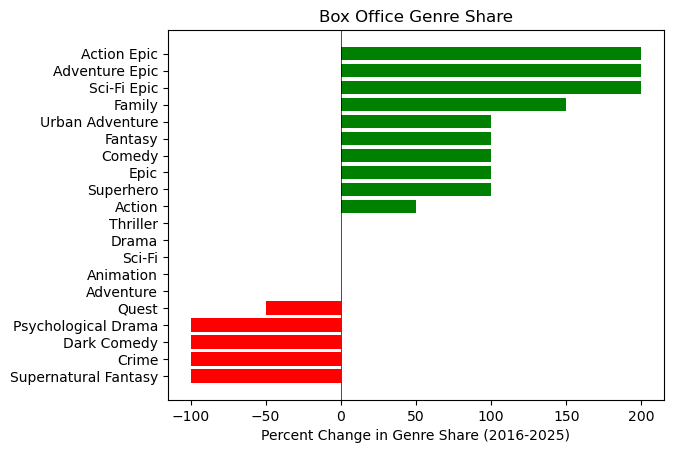

In [11]:
percent = percent.sort_values(ascending=True)

fig, ax = plt.subplots()
colors = ['green' if val >=0 else 'red' for val in percent.values] #creates color split with positive and negative changes
bars = ax.barh(percent.index, percent.values, color=colors)
for bar, val in zip(bars, percent.values): #combines the separate bar graphs
    sign = '+' if val >=0 else '-'
ax.axvline(x=0, color='black', linewidth=0.5) #creates a vertical line at 0
ax.set_title('Box Office Genre Share')
ax.set_xlabel('Percent Change in Genre Share (2016-2025)')
fig.savefig('boxofficepercentchange.jpg')